In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

df = pd.read_csv('global_temp_scenarios.csv')

hist = df[df['scenario'] == 'historical']
s245 = df[df['scenario'] == 'ssp245']
s585 = df[df['scenario'] == 'ssp585']

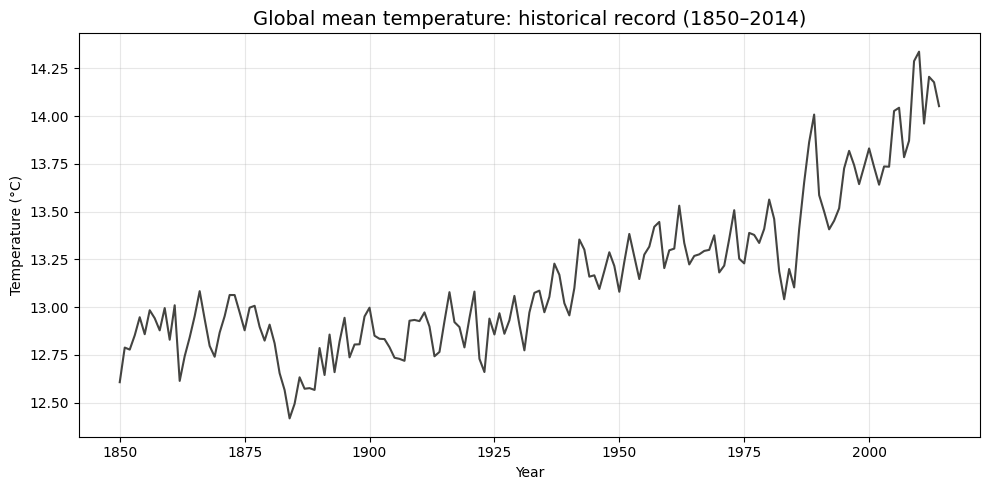

In [3]:
# Plot 1: Raw historical temperature trend (1850-2014)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist['year'], hist['tas_celsius'], color='#444441', linewidth=1.5)
ax.set_title('Global mean temperature: historical record (1850–2014)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_historical.png', dpi=150)
plt.show()

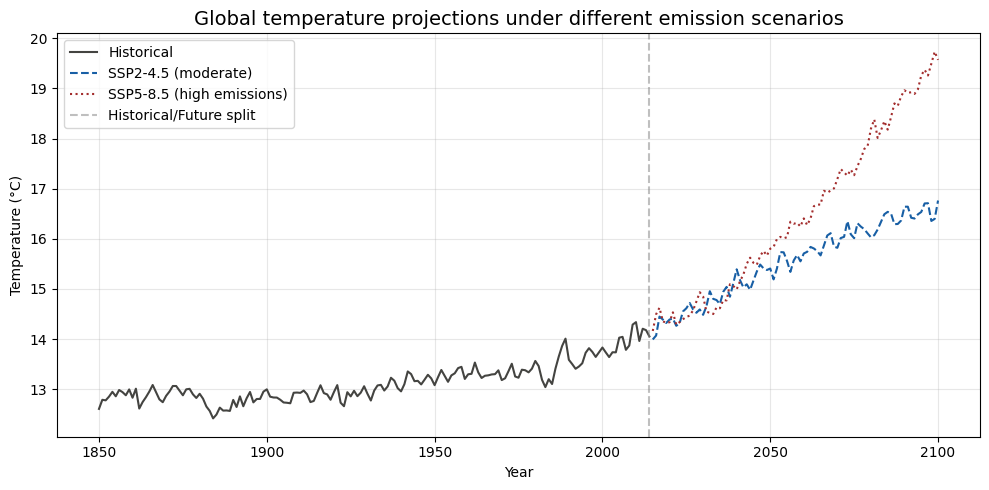

In [4]:
# Plot 2: All 3 scenarios on one chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist['year'], hist['tas_celsius'], color='#444441', label='Historical', linewidth=1.5)
ax.plot(s245['year'], s245['tas_celsius'], color='#185FA5', label='SSP2-4.5 (moderate)', linewidth=1.5, linestyle='--')
ax.plot(s585['year'], s585['tas_celsius'], color='#A32D2D', label='SSP5-8.5 (high emissions)', linewidth=1.5, linestyle=':')
ax.axvline(x=2014, color='gray', linestyle='--', alpha=0.5, label='Historical/Future split')
ax.set_title('Global temperature projections under different emission scenarios', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_all_scenarios.png', dpi=150)
plt.show()

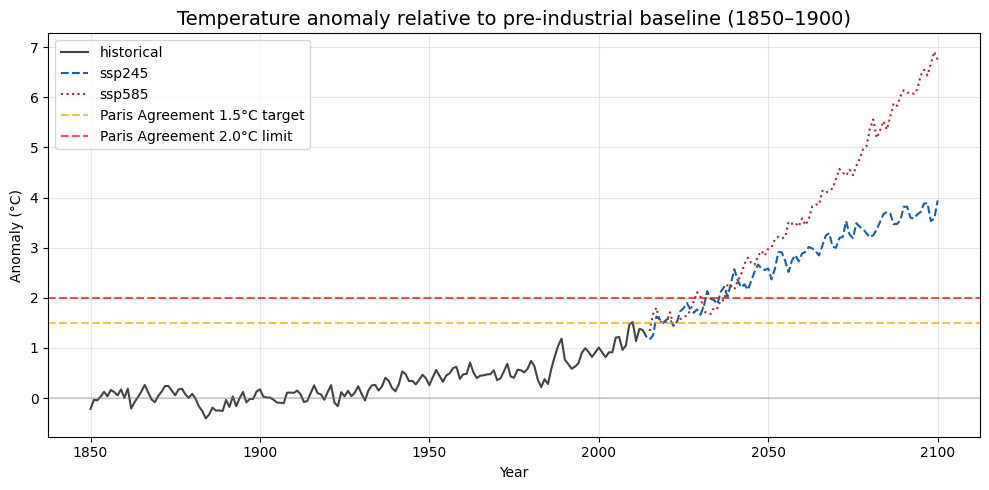

In [5]:
# Plot 3: Temperature anomaly relative to 1850-1900 baseline
baseline = hist[hist['year'] <= 1900]['tas_celsius'].mean()
df['anomaly'] = df['tas_celsius'] - baseline

fig, ax = plt.subplots(figsize=(10, 5))
for scenario, color, ls in [('historical','#444441','-'), ('ssp245','#185FA5','--'), ('ssp585','#A32D2D',':')]:
    d = df[df['scenario'] == scenario]
    ax.plot(d['year'], d['anomaly'], color=color, label=scenario, linewidth=1.5, linestyle=ls)
ax.axhline(y=1.5, color='orange', linestyle='--', alpha=0.7, label='Paris Agreement 1.5°C target')
ax.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='Paris Agreement 2.0°C limit')
ax.axhline(y=0, color='gray', alpha=0.3)
ax.set_title('Temperature anomaly relative to pre-industrial baseline (1850–1900)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Anomaly (°C)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_anomaly.png', dpi=150)
plt.show()

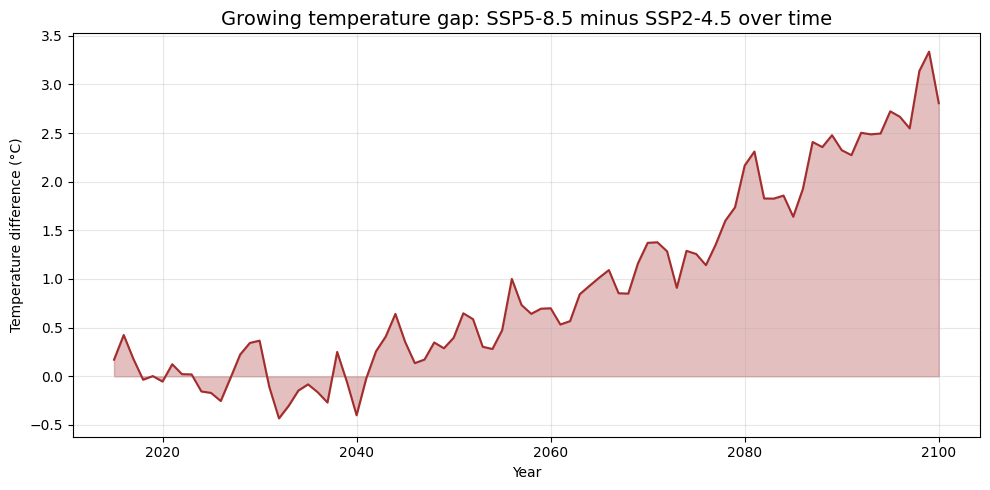

In [6]:
# Plot 4: Divergence between scenarios over time (gap between ssp585 and ssp245)
merged = pd.merge(s245, s585, on='year', suffixes=('_245','_585'))
merged['gap'] = merged['tas_celsius_585'] - merged['tas_celsius_245']

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(merged['year'], merged['gap'], color='#A32D2D', alpha=0.3)
ax.plot(merged['year'], merged['gap'], color='#A32D2D', linewidth=1.5)
ax.set_title('Growing temperature gap: SSP5-8.5 minus SSP2-4.5 over time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature difference (°C)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot4_divergence.png', dpi=150)
plt.show()

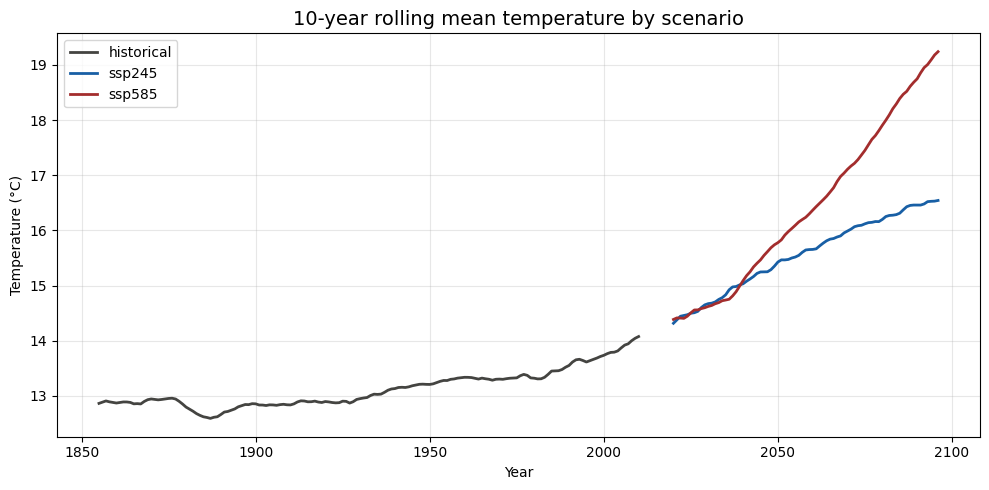

In [7]:
# Plot 5: 10-year rolling average to smooth noise
df_sorted = df.sort_values(['scenario','year'])
df_sorted['rolling'] = df_sorted.groupby('scenario')['tas_celsius'].transform(lambda x: x.rolling(10, center=True).mean())

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'historical': '#444441', 'ssp245': '#185FA5', 'ssp585': '#A32D2D'}
for scenario, grp in df_sorted.groupby('scenario'):
    ax.plot(grp['year'], grp['rolling'], color=colors[scenario], label=scenario, linewidth=2)
ax.set_title('10-year rolling mean temperature by scenario', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_rolling.png', dpi=150)
plt.show()

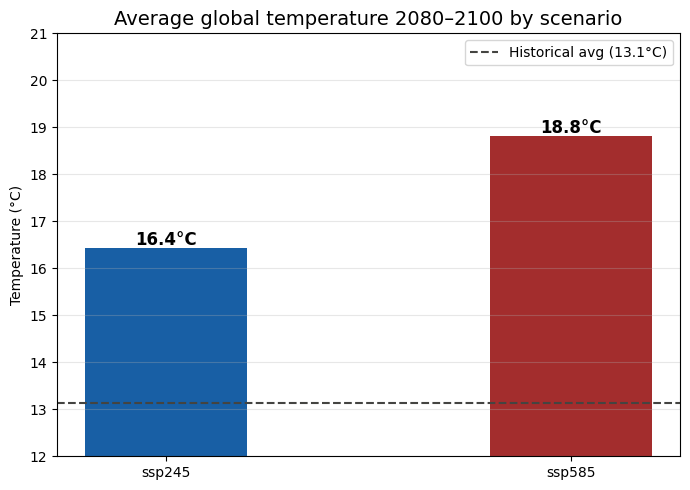

In [8]:
# Plot 6: End-of-century bar comparison (2080-2100 average per scenario)
end_century = df[df['year'] >= 2080].groupby('scenario')['tas_celsius'].mean().reset_index()
colors_bar = ['#185FA5', '#A32D2D']
scenarios_bar = ['ssp245', 'ssp585']
vals = [end_century[end_century['scenario']==s]['tas_celsius'].values[0] for s in scenarios_bar]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(scenarios_bar, vals, color=colors_bar, width=0.4)
ax.axhline(y=hist['tas_celsius'].mean(), color='#444441', linestyle='--', label=f'Historical avg ({hist["tas_celsius"].mean():.1f}°C)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.1f}°C', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Average global temperature 2080–2100 by scenario', fontsize=14)
ax.set_ylabel('Temperature (°C)')
ax.set_ylim(12, 21)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot6_endcentury.png', dpi=150)
plt.show()